# PEDS-afim — protocolo experimental do artigo

Este notebook gera os resultados para as seções 4 e 5 do manuscrito: curvas FE × N, expoentes de escala e testes estatísticos comparando PEDS físico, PEDS-afim e NN-only nos benchmarks Fourier/Fisher.

In [1]:
# Célula 1 — setup
%matplotlib inline
import os, sys, torch, pandas as pd
sys.path.append(os.path.abspath('..'))

from src.peds_experiments import (
    EXPERIMENTS, ARTICLE_MODELS, ARTICLE_LABELS,
    run_article_sweep, save_article_analysis_tables,
    plot_article_learning_curves, plot_article_result_tables,
)

DATA_ROOT = os.path.abspath('../data')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Protocolo descrito no artigo.
SIZES = (64, 128, 256, 512, 1024, 2048, 4096)
SEEDS = range(10)
MAX_EPOCHS = 400
BATCH = 64
LR = 5e-5
EVAL_EVERY = 10
PATIENCE = 8
MIN_EPOCHS = 40

print('device:', DEVICE)
print('problemas:', list(EXPERIMENTS))
print('modelos:', [ARTICLE_LABELS[m] for m in ARTICLE_MODELS])
print('N:', SIZES, '| seeds:', list(SEEDS))

[PEDS Init] Aceleração de Hardware configurada para: cuda
[PEDS Init] Executando em modo Single-Process / Local.
device: cuda
problemas: ['Fourier(16)', 'Fourier(25)', 'Fisher(16)', 'Fisher(25)']
modelos: ['PEDS físico', 'PEDS-afim', 'NN-only']
N: (64, 128, 256, 512, 1024, 2048, 4096) | seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## Execução principal

Roda uma linha por problema, modelo, tamanho de treino e semente. O resultado granular é salvo incrementalmente em `results/article_seed_results.csv`; se a execução cair, rode a célula de novo e o pipeline pulará automaticamente as combinações já concluídas.


In [2]:
raw = run_article_sweep(
    DATA_ROOT,
    sizes=SIZES,
    seeds=SEEDS,
    device=DEVICE,
    max_epochs=MAX_EPOCHS,
    lr=LR,
    batch=BATCH,
    eval_every=EVAL_EVERY,
    patience=PATIENCE,
    min_epochs=MIN_EPOCHS,
    save_dir='./results',
    verbose=True,
)
raw.head()

Retomando de ./results/article_seed_results.csv: 789 combinações já concluídas.
Fourier(16) N=  64 seed= 0 peds      skip=checkpoint
Fourier(16) N=  64 seed= 1 peds      skip=checkpoint
Fourier(16) N=  64 seed= 2 peds      skip=checkpoint
Fourier(16) N=  64 seed= 3 peds      skip=checkpoint
Fourier(16) N=  64 seed= 4 peds      skip=checkpoint
Fourier(16) N=  64 seed= 5 peds      skip=checkpoint
Fourier(16) N=  64 seed= 6 peds      skip=checkpoint
Fourier(16) N=  64 seed= 7 peds      skip=checkpoint
Fourier(16) N=  64 seed= 8 peds      skip=checkpoint
Fourier(16) N=  64 seed= 9 peds      skip=checkpoint
Fourier(16) N=  64 seed= 0 peds_afim skip=checkpoint
Fourier(16) N=  64 seed= 1 peds_afim skip=checkpoint
Fourier(16) N=  64 seed= 2 peds_afim skip=checkpoint
Fourier(16) N=  64 seed= 3 peds_afim skip=checkpoint
Fourier(16) N=  64 seed= 4 peds_afim skip=checkpoint
Fourier(16) N=  64 seed= 5 peds_afim skip=checkpoint
Fourier(16) N=  64 seed= 6 peds_afim skip=checkpoint
Fourier(16) N=  64 

,problem,data,model,model_label,N,seed,test_fe,val_fe,best_epoch,epochs_run,w,n_params
0,Fourier(16),fourier16,peds,PEDS físico,64,0,0.1034,0.0986,400,NaN,NaN,20753.0
1,Fourier(16),fourier16,peds,PEDS físico,64,1,0.1029,0.0981,400,NaN,NaN,20753.0
2,Fourier(16),fourier16,peds,PEDS físico,64,2,0.1028,0.0980,400,NaN,NaN,20753.0
3,Fourier(16),fourier16,peds,PEDS físico,64,3,0.1033,0.0985,400,NaN,NaN,20753.0
4,Fourier(16),fourier16,peds,PEDS físico,64,4,0.1029,0.0981,400,NaN,NaN,20753.0


## Agregação, expoentes e testes

Gera tabelas agregadas, expoentes `FE ~ N^alpha`, Wilcoxon sobre as curvas de aprendizado e testes pareados por semente em cada `N`.

In [3]:
summary, alphas, curve_tests, seed_tests, paths = save_article_analysis_tables(raw, save_dir='./results')

print('CSV gerados:')
for name, path in paths.items():
    print(f'  {name}: {path}')

display(summary)
display(alphas)
display(curve_tests)

CSV gerados:
  article_summary.csv: ./results/article_summary.csv
  article_exponents.csv: ./results/article_exponents.csv
  article_curve_wilcoxon.csv: ./results/article_curve_wilcoxon.csv
  article_seed_tests.csv: ./results/article_seed_tests.csv


,problem,model,model_label,N,n_seeds,mean_fe,median_fe,std_fe,q25_fe,q75_fe,mean_best_epoch,mean_w,n_params
0,Fisher(16),nn_only,NN-only,64,10,0.17237,0.16925,0.007709,0.167850,0.174925,400.0,NaN,20769.0
1,Fisher(16),nn_only,NN-only,128,10,0.15230,0.15270,0.005224,0.148450,0.155900,400.0,NaN,20769.0
2,Fisher(16),nn_only,NN-only,256,10,0.13130,0.13095,0.003286,0.128800,0.134050,392.0,NaN,20769.0
3,Fisher(16),nn_only,NN-only,512,10,0.11112,0.11225,0.005355,0.111000,0.114675,368.0,NaN,20769.0
4,Fisher(16),nn_only,NN-only,1024,10,0.10304,0.10445,0.009258,0.099600,0.109725,324.0,NaN,20769.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,Fourier(25),peds_afim,PEDS-afim,256,10,0.18640,0.21675,0.056567,0.152950,0.223100,400.0,NaN,23092.0
80,Fourier(25),peds_afim,PEDS-afim,512,10,0.13649,0.15950,0.059215,0.073900,0.186275,399.0,NaN,23092.0
81,Fourier(25),peds_afim,PEDS-afim,1024,10,0.06842,0.05595,0.019887,0.052950,0.089375,398.0,NaN,23092.0
82,Fourier(25),peds_afim,PEDS-afim,2048,10,0.04489,0.04460,0.002688,0.042750,0.046725,393.0,NaN,23092.0


,problem,model,model_label,alpha_median_curve,log_intercept,alpha_seed_mean,alpha_seed_std,n_seed_alphas
0,Fisher(16),nn_only,NN-only,-0.137518,-1.249177,-0.146384,0.042589,10
1,Fisher(16),peds,PEDS físico,-0.228754,-1.114206,-0.231596,0.013390,10
2,Fisher(16),peds_afim,PEDS-afim,-0.449073,0.694087,-0.462293,0.061731,10
3,Fisher(25),nn_only,NN-only,-0.090653,-1.476739,-0.088323,0.020549,10
4,Fisher(25),peds,PEDS físico,-0.173192,-1.466894,-0.174455,0.011800,10
5,Fisher(25),peds_afim,PEDS-afim,-0.406232,0.422676,-0.388714,0.061429,10
6,Fourier(16),nn_only,NN-only,-0.176258,-1.297596,-0.175330,0.080386,10
7,Fourier(16),peds,PEDS físico,-0.038620,-2.174206,-0.038856,0.001124,10
8,Fourier(16),peds_afim,PEDS-afim,-0.675732,2.233740,-0.698239,0.153781,10
9,Fourier(25),nn_only,NN-only,-0.069561,-1.877908,-0.068697,0.032877,10


,scope,problem,N,contrast,statistic,p_value,median_delta_a_minus_b,n_pairs
0,global_problem_N,all,all,PEDS físico vs PEDS-afim,37.000000,4.211068e-05,-0.06175,28
1,global_problem_N,all,all,PEDS físico vs NN-only,9.000000,2.458692e-07,-0.03880,28
2,global_problem_N,all,all,PEDS-afim vs NN-only,108.000000,2.983319e-02,0.02560,28
3,global_problem_N,all,all,PEDS físico vs PEDS-afim vs NN-only,21.428571,2.222516e-05,NaN,28
4,curve_over_N,Fisher(16),all,PEDS físico vs PEDS-afim,1.000000,3.125000e-02,-0.03620,7
5,curve_over_N,Fisher(16),all,PEDS físico vs NN-only,0.000000,1.562500e-02,-0.03950,7
6,curve_over_N,Fisher(16),all,PEDS-afim vs NN-only,10.000000,5.781250e-01,-0.00190,7
7,curve_over_N,Fisher(25),all,PEDS físico vs PEDS-afim,1.000000,3.125000e-02,-0.03545,7
8,curve_over_N,Fisher(25),all,PEDS físico vs NN-only,0.000000,1.562500e-02,-0.04985,7
9,curve_over_N,Fisher(25),all,PEDS-afim vs NN-only,12.000000,8.125000e-01,-0.01400,7


## Figuras para os resultados

As figuras são salvas em `figs/` e podem ser usadas diretamente nas seções 4.1 e 4.2.

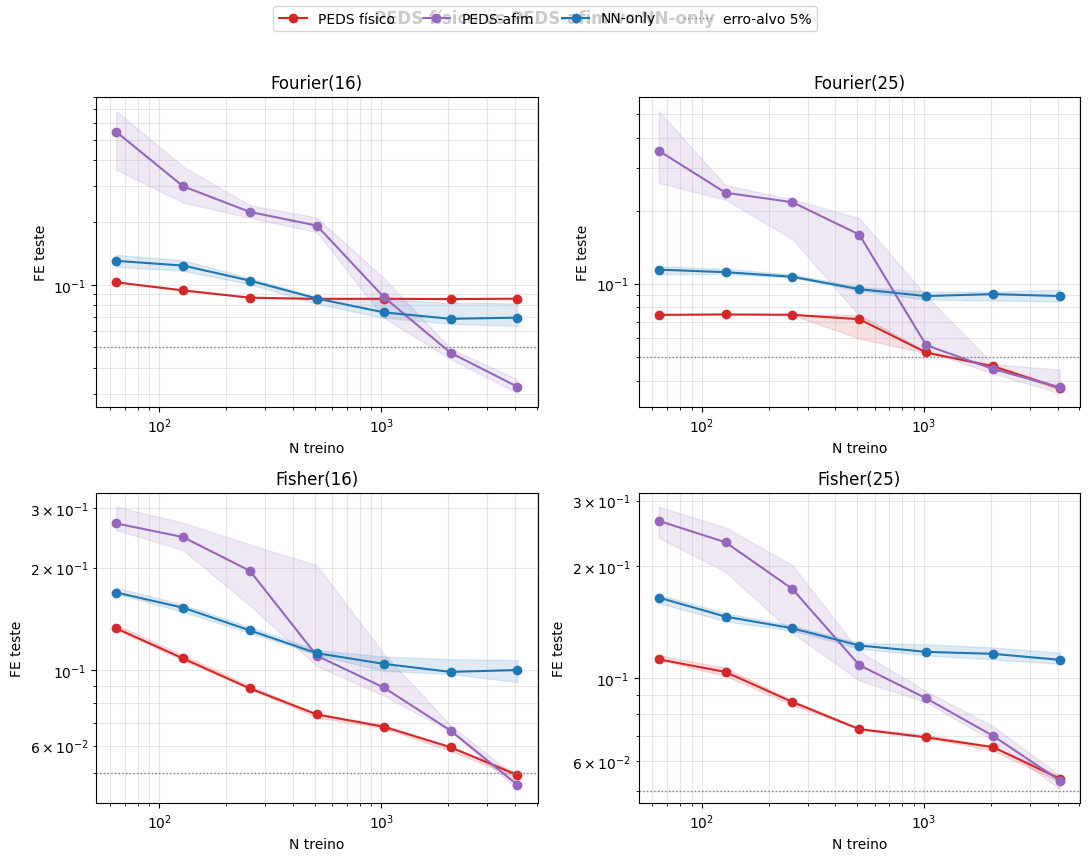

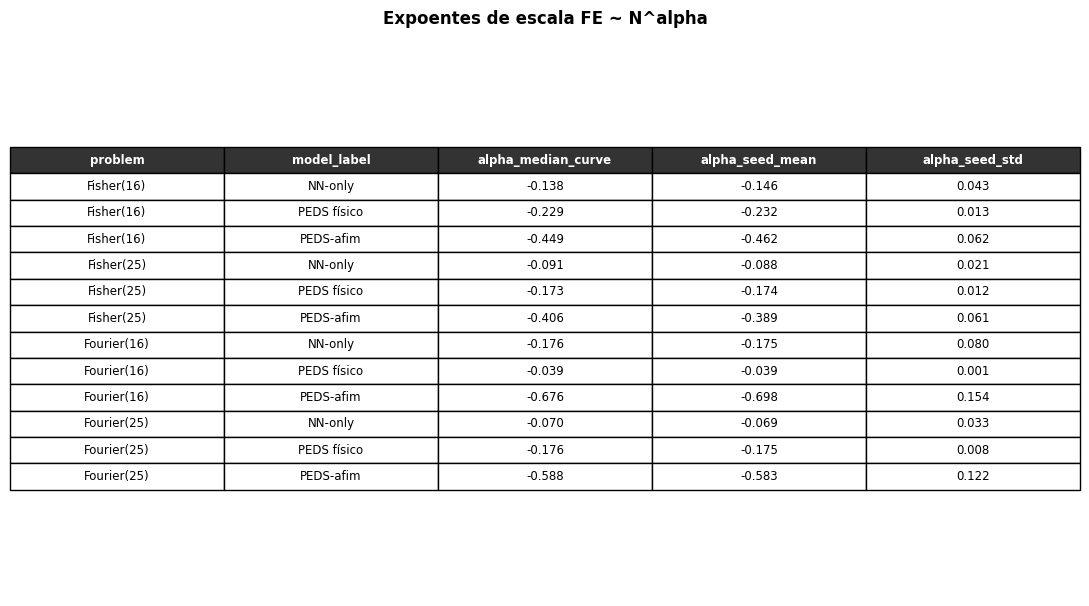

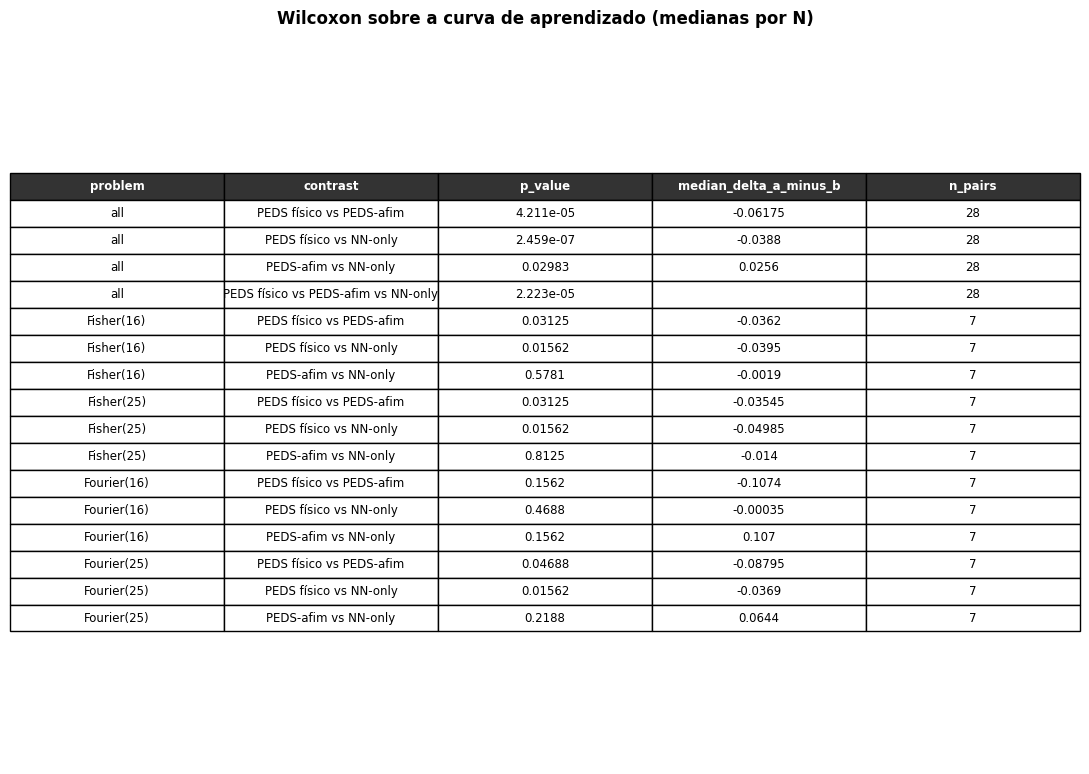

figura de curvas: ./figs/article_learning_curves.png
tabelas: ['./figs/article_alpha_table.png', './figs/article_curve_wilcoxon_table.png']


In [4]:
curve_path = plot_article_learning_curves(raw, save_dir='./figs')
table_paths = plot_article_result_tables(alphas, curve_tests, save_dir='./figs')
print('figura de curvas:', curve_path)
print('tabelas:', table_paths)

## Inspeção dos testes por N

A tabela completa dos testes pareados por semente fica em `results/article_seed_tests.csv`. Use esta célula para filtrar o contraste central do artigo.

In [5]:
central = seed_tests[seed_tests['contrast'] == 'PEDS físico vs PEDS-afim'].copy()
display(central.sort_values(['problem', 'N']))

,scope,problem,N,contrast,statistic,p_value,median_delta_a_minus_b,n_pairs
0,paired_seeds_at_N,Fisher(16),64,PEDS físico vs PEDS-afim,0.0,0.001953,-0.136400,10
4,paired_seeds_at_N,Fisher(16),128,PEDS físico vs PEDS-afim,0.0,0.001953,-0.137200,10
8,paired_seeds_at_N,Fisher(16),256,PEDS físico vs PEDS-afim,0.0,0.001953,-0.109850,10
12,paired_seeds_at_N,Fisher(16),512,PEDS físico vs PEDS-afim,0.0,0.001953,-0.036750,10
16,paired_seeds_at_N,Fisher(16),1024,PEDS físico vs PEDS-afim,0.0,0.001953,-0.020800,10
20,paired_seeds_at_N,Fisher(16),2048,PEDS físico vs PEDS-afim,0.0,0.001953,-0.007950,10
24,paired_seeds_at_N,Fisher(16),4096,PEDS físico vs PEDS-afim,7.0,0.037109,0.002750,10
28,paired_seeds_at_N,Fisher(25),64,PEDS físico vs PEDS-afim,0.0,0.001953,-0.151850,10
32,paired_seeds_at_N,Fisher(25),128,PEDS físico vs PEDS-afim,0.0,0.001953,-0.129550,10
36,paired_seeds_at_N,Fisher(25),256,PEDS físico vs PEDS-afim,0.0,0.001953,-0.087800,10


## Execução rápida de sanidade

Para validar mudanças no código sem rodar o protocolo completo, execute a célula abaixo. Ela usa um único problema, dois tamanhos de treino e duas sementes.

In [ ]:
# smoke = run_article_sweep(
#     DATA_ROOT,
#     problems=['Fourier(16)'],
#     sizes=(64, 128),
#     seeds=range(2),
#     device=DEVICE,
#     max_epochs=30,
#     eval_every=5,
#     patience=3,
#     min_epochs=10,
#     save_dir='./results/smoke',
#     verbose=True,
# )
# display(smoke)